## CSC 522 Code Part

April 28, 2026

Section 002

Group 13

Members:
- Cynthia Espinoza-Arredondo
- Demaris Ghide
- Mia Glenn
- JonCarlo Migaly

In [ ]:
# Import the drive module from Google Colab
from google.colab import drive

# Mount your Google Drive so Colab can access your files
# After running this, you'll get a link to authorize access
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the os module to interact with the file system
import os

# Set the path to your ECONet folder in Google Drive
dataset_path = '/content/drive/MyDrive/ECONet'

# List and print all files inside the ECONet folder
# This confirms your folder is loaded correctly
os.listdir(dataset_path)

['ECONET_QC_Readme.xlsx', 'train.csv', 'test.csv', 'ECONET.md', 'full']

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import os
from sklearn.model_selection import train_test_split

# random seed so we all get same results
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# load train.csv
train_path = '/content/drive/MyDrive/ECONet/train.csv'
df = pd.read_csv(train_path)

print(f"Full train.csv shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nClass distribution of full data:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(4))

# convert Ob to datetime
df['Ob'] = pd.to_datetime(df['Ob'])

# take stratified 20% sample to preserves 3.57% TRUE ratio
df_sample, _ = train_test_split(
    df,
    test_size=0.80,
    stratify=df['target'],
    random_state=SEED
)

# sort chronologically after sampling
df_sample = df_sample.sort_values('Ob').reset_index(drop=True)

print(f"\nSample shape (20%): {df_sample.shape}")
print(f"\nClass distribution of sample:")
print(df_sample['target'].value_counts())
print(df_sample['target'].value_counts(normalize=True).round(4))

df_sample.head()

Full train.csv shape: (6593274, 9)

Column names:
['Station', 'Ob', 'value', 'measure', 'target', 'R_flag', 'I_flag', 'Z_flag', 'B_flag']

Class distribution of full data:
target
False    6358102
True      235172
Name: count, dtype: int64
target
False    0.9643
True     0.0357
Name: proportion, dtype: float64

Sample shape (20%): (1318654, 9)

Class distribution of sample:
target
False    1271620
True       47034
Name: count, dtype: int64
target
False    0.9643
True     0.0357
Name: proportion, dtype: float64


,Station,Ob,value,measure,target,R_flag,I_flag,Z_flag,B_flag
0,BEAR,2021-01-01 00:00:00,0.205,sm,False,0,-1,-1,2
1,CAST,2021-01-01 00:00:00,0.237,sm,False,0,-1,-1,1
2,SPRU,2021-01-01 00:00:00,0.251,sm,False,0,-1,-1,1
3,SALI,2021-01-01 00:00:00,0.511,sm,False,2,-1,-1,0
4,ROCK,2021-01-01 00:01:00,0.290,sm,False,0,-1,-1,1


The original code took the first 20% of observations chronologically which captured mostly January and February, the two months with the highest true error rates in the entire dataset (11.1% and 10.2% respectively). This produced a severely distorted sample where true errors were overrepresented at 10.36% nearly three times higher than the actual 3.57% rate in the full dataset.

## what is Changed
The fix replaces the chronological splite with a stratified random sample using train_test_split with stratify=df['target'], which guarantees that the 20% sample preserves the exact class distribution of the full dataset 96.43% FALSE and 3.57% TRUE. The sample is then sorted chronologically after sampling so the time order is still maintained for any temporal analysis. This single change ensures that all downstream EDA, preprocessing, and modeling is based on a truly representative sample of the full training data.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

# basic info
print("Shape:")
print(df_sample.shape)

print("\nData Types:")
print(df_sample.dtypes)

print("\nMissing Values:")
print(df_sample.isnull().sum())

print("\nBasic Statistics:")
print(df_sample.describe())

Shape:
(1318654, 9)

Data Types:
Station            object
Ob         datetime64[ns]
value             float64
measure            object
target               bool
R_flag              int64
I_flag              int64
Z_flag              int64
B_flag              int64
dtype: object

Missing Values:
Station    0
Ob         0
value      0
measure    0
target     0
R_flag     0
I_flag     0
Z_flag     0
B_flag     0
dtype: int64

Basic Statistics:
                                  Ob         value        R_flag  \
count                        1318654  1.318654e+06  1.318654e+06   
mean   2021-06-16 11:15:21.393588480  9.003836e+01  5.240647e-01   
min              2021-01-01 00:00:00 -9.190000e+01 -1.000000e+00   
25%              2021-03-26 04:30:00  2.140000e-01  0.000000e+00   
50%              2021-06-18 17:33:30  4.670000e-01  0.000000e+00   
75%              2021-09-02 09:24:00  1.123000e+01  0.000000e+00   
max              2021-12-17 00:00:00  3.053000e+03  4.000000e+00   
std      

## Basic Structural Analysis

 The dataset contains 1,318,654 rows and 9 columns, representing 20% of the full 6,593,274 row training dataset. The stratified sampling correctly preserved the original class distribution of 96.43% false positives and 3.57% true errors.

 All columns are correctly formatted. The timestamp column Ob is stored as datetime64, the sensor reading value is stored as float64, the four QA flag columns R_flag, I_flag, Z_flag and B_flag are stored as integers, and the categorical columns Station and measure are stored as objects. No type conversions were necessary.

 A null check across all 9 columns revealed zero missing values throughout the entire sample. The dataset is completely clean and requires no imputation strategy at this stage.

 The value column shows extreme right skew with a mean of 90.95 but a median of just 0.467, spanning a wide range from -92.4 to 3,053 — reflecting the fact that very different sensor types are mixed together in a single column. The flag columns I_flag and Z_flag both have their 25th, 50th and 75th percentiles at -1, confirming that more than 75% of observations have these QA checks marked as not applicable. The B_flag column has a median of 1 and R_flag a median of 0, indicating that most flagged readings pass the range and buddy checks without issue.

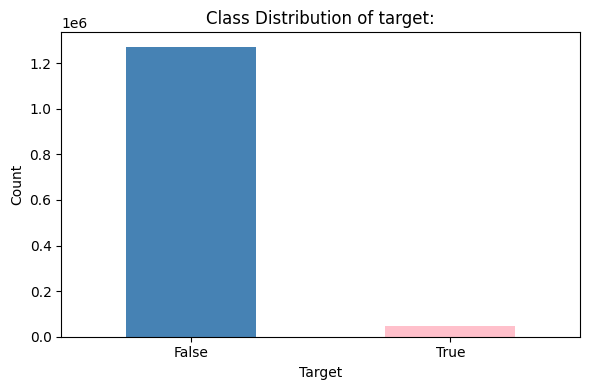

target
False    0.9643
True     0.0357
Name: proportion, dtype: float64


In [ ]:
# EDA

# class distribution bar chart
plt.figure(figsize=(6, 4))
df_sample['target'].value_counts().plot(kind='bar', color=['steelblue', 'pink'])
plt.title('Class Distribution of target:')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df_sample['target'].value_counts(normalize=True).round(4))

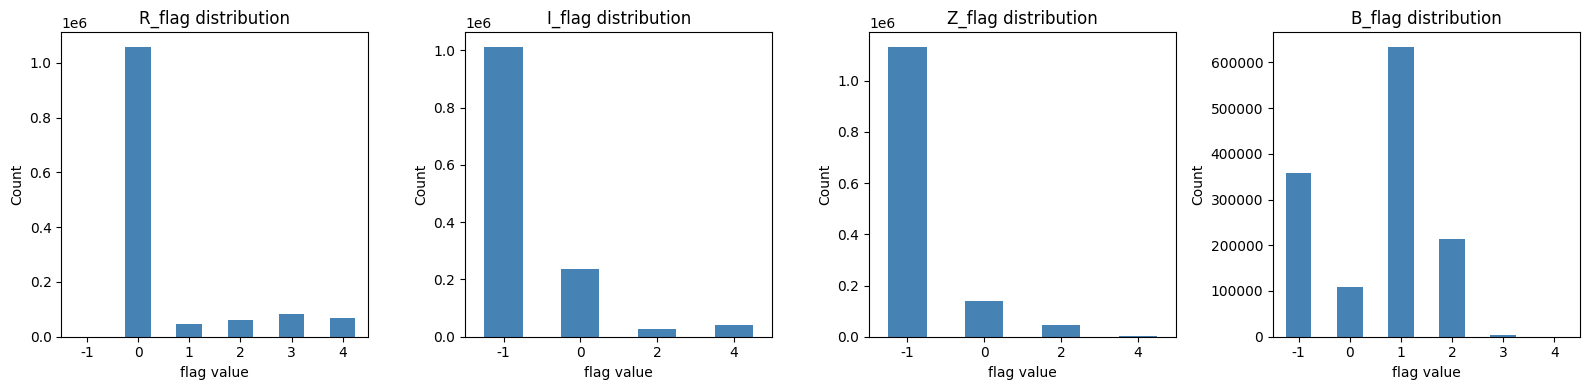


R_flag value counts:
R_flag
-1         92
 0    1058771
 1      47227
 2      61913
 3      82505
 4      68146
Name: count, dtype: int64

I_flag value counts:
I_flag
-1    1012764
 0     236017
 2      27237
 4      42636
Name: count, dtype: int64

Z_flag value counts:
Z_flag
-1    1132137
 0     137912
 2      47567
 4       1038
Name: count, dtype: int64

B_flag value counts:
B_flag
-1    358039
 0    109372
 1    633866
 2    214652
 3      2721
 4         4
Name: count, dtype: int64

--- R_flag distribution by target ---
target    Total  Error rate (%)
R_flag                         
-1           92            14.1
 0      1058771             4.0
 1        47227             5.3
 2        61913             1.2
 3        82505             0.4
 4        68146             1.2

--- I_flag distribution by target ---
target    Total  Error rate (%)
I_flag                         
-1      1012764             3.4
 0       236017             2.3
 2        27237             4.3
 4        42

In [ ]:
# EDA

# flag column distributions
flag_cols = ['R_flag', 'I_flag', 'Z_flag', 'B_flag']

fix, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, flag_cols):
  df_sample[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
  ax.set_title(f'{col} distribution')
  ax.set_xlabel('flag value')
  ax.set_ylabel('Count')
  ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


# print exact counts
for col in flag_cols:
  print(f"\n{col} value counts:")
  print(df_sample[col].value_counts().sort_index())

  flag_cols = ['R_flag', 'I_flag', 'Z_flag', 'B_flag']

for col in flag_cols:
    print(f"\n--- {col} distribution by target ---")
    flag_tbl = df_sample.groupby([col, "target"]).size().unstack(fill_value=0)
    flag_tbl["Total"] = flag_tbl.sum(axis=1)
    flag_tbl["Error rate (%)"] = (flag_tbl[True] / flag_tbl["Total"] * 100).round(1)
    print(flag_tbl[["Total", "Error rate (%)"]].to_string())

##Column Distributions
The distribution of the four QA flag columns reveals that each check is applied very differently across the 1,318,654 observations. R_flag is the most broadly applied check with only 106 not applicable values and 80.3% of observations passing at level 0, while the remaining 259,041 are spread across severity levels 1 through 4. I_flag and Z_flag have the highest not applicable rates at 76.8% and 85.9% respectively, confirming that these checks are only run on a small subset of measures that support paired sensor or spatial comparisons. B_flag shows the most varied distribution with 634,896 observations at level 1 which carries only a 0.9% true error rate and just 2,729 observations at level 3 which despite its rarity carries the strongest true error signal in the entire dataset at 33.8%.

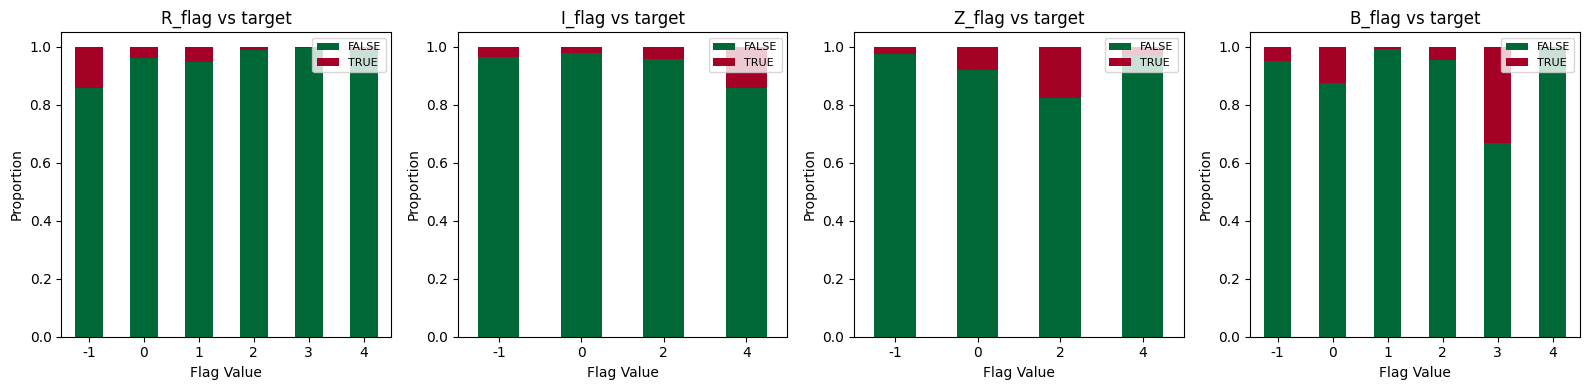

In [ ]:
# EDA

# flag values vs target
# to show whether higher flag scores are associated with TRUE errors
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, flag_cols):
  df_sample.groupby(col)['target'].value_counts(normalize=True).unstack().plot(
      kind='bar', ax=ax, stacked=True, colormap='RdYlGn_r'
  )
  ax.set_title(f'{col} vs target')
  ax.set_xlabel('Flag Value')
  ax.set_ylabel('Proportion')
  ax.tick_params(axis='x', rotation=0)
  ax.legend(['FALSE', 'TRUE'], loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

##Flag Values vs Target Distribution
To investigate whether higher QA flag severity levels are associated with a greater proportion of true sensor errors, four stacked proportional bar charts were produced using normalized proportions rather than raw counts essential given the severe 27:1 class imbalance which would render true errors nearly invisible if raw counts were used instead. The charts confirm that Z_flag shows the clearest and most consistent pattern with error proportion rising steadily as severity increases, I_flag=4 produces a sharp spike in error proportion at its highest severity level, and B_flag=3 shows the highest error proportion of any single flag value across all four charts consistent with the 33.8% true error rate identified in the full dataset analysis. R_flag presents a counterintuitive decreasing error proportion at higher severity levels confirming it is not a reliable standalone predictor.

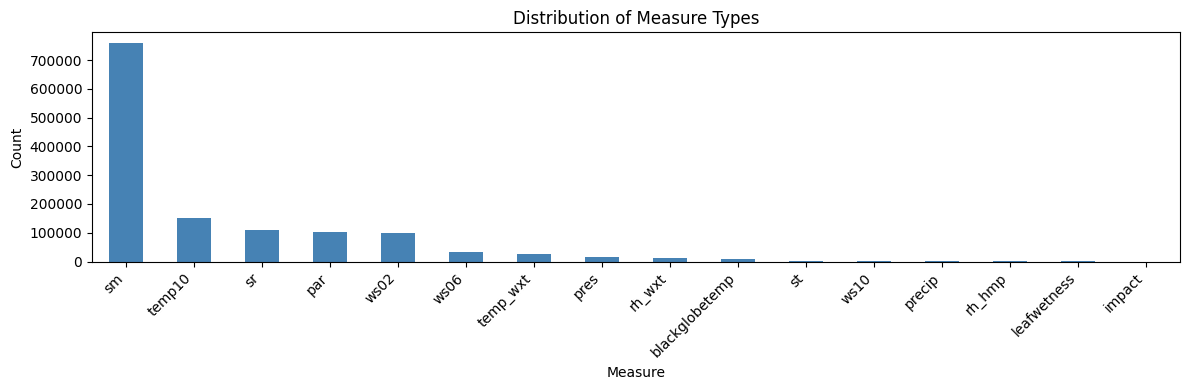


Number of Unique Measure Types: 16
measure
sm                758452
temp10            150228
sr                108471
par               101032
ws02              100599
ws06               34143
temp_wxt           25018
pres               14984
rh_wxt             12482
blackglobetemp      9280
st                  1528
ws10                1406
precip               556
rh_hmp               280
leafwetness          194
impact                 1
Name: count, dtype: int64
Measure in persentage
measure
sm                0.5752
temp10            0.1139
sr                0.0823
par               0.0766
ws02              0.0763
ws06              0.0259
temp_wxt          0.0190
pres              0.0114
rh_wxt            0.0095
blackglobetemp    0.0070
st                0.0012
ws10              0.0011
precip            0.0004
rh_hmp            0.0002
leafwetness       0.0001
impact            0.0000
Name: proportion, dtype: float64


In [ ]:
# EDA

# measure type distributions
plt.figure(figsize=(12, 4))
df_sample['measure'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Measure Types')
plt.xlabel('Measure')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nNumber of Unique Measure Types: {df_sample['measure'].nunique()}")
print(df_sample['measure'].value_counts())

print('Measure in persentage' )

print(df_sample['measure'].value_counts(normalize=True).round(4))


The dataset contains 15 unique sensor measure types across the 1,318,654 observations in the stratified sample. The distribution is heavily uneven sm (soil moisture) dominates with 758,224 observations (57.5% of the sample) followed by temp10 with 150,069 and sr with 108,571. At the other extreme leafwetness has only 188 observations, rh_hmp has 292, and precip has 562  making these three measures extremely rare in the dataset. This uneven distribution is important for modeling because the model will see vastly more examples of sm than any other measure during training, potentially biasing it toward the behavior of soil moisture readings. This is particularly concerning given that sm has only a 0.6% true error rate — the second lowest of all measures  meaning the model could learn to almost always predict false positive for the dominant measure and still achieve a high overall accuracy while performing poorly on the rarer but more error-prone measures like precipand ws10 .

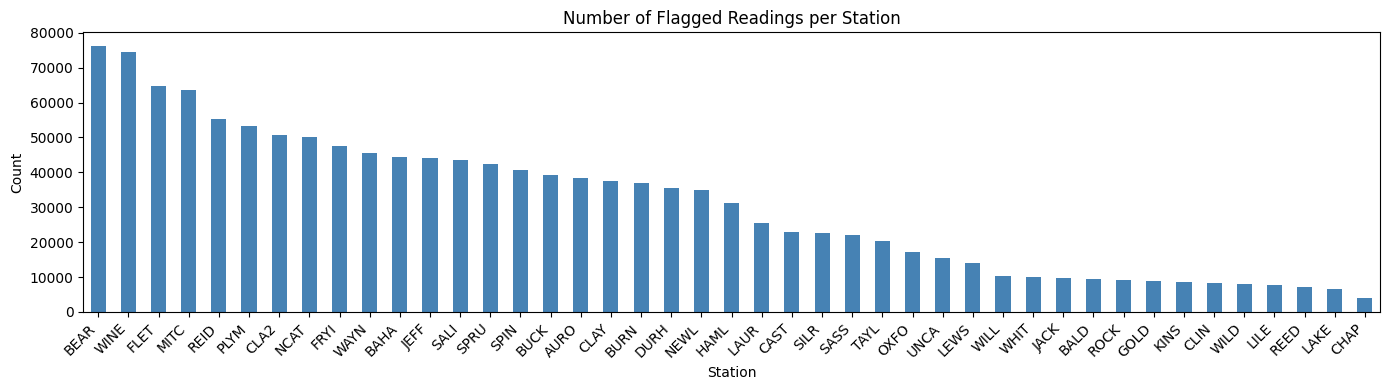


Number of Unique Stations: 43


In [ ]:
# EDA

# station distribution
plt.figure(figsize=(14, 4))
df_sample['Station'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Number of Flagged Readings per Station')
plt.xlabel('Station')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nNumber of Unique Stations: {df_sample['Station'].nunique()}")


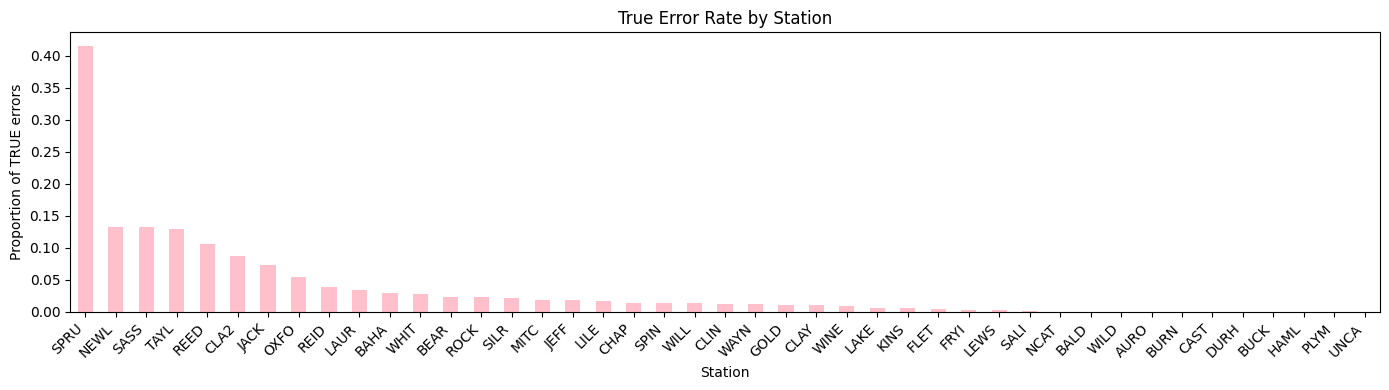


Top 10 Stations by true error rate:
Station
SPRU    0.415419
NEWL    0.132769
SASS    0.132521
TAYL    0.129876
REED    0.105867
CLA2    0.086554
JACK    0.072844
OXFO    0.054317
REID    0.038380
LAUR    0.033849
Name: target, dtype: float64


In [ ]:
# EDA

# true error rate by station
# important for our interpretable model to see which stations have most true errors
station_error_rate = df_sample.groupby('Station')['target'].apply(
    lambda x: (x == True).mean()
).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
station_error_rate.plot(kind='bar', color='pink')
plt.title('True Error Rate by Station')
plt.xlabel('Station')
plt.ylabel('Proportion of TRUE errors')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Stations by true error rate:")
print(station_error_rate.head(10))

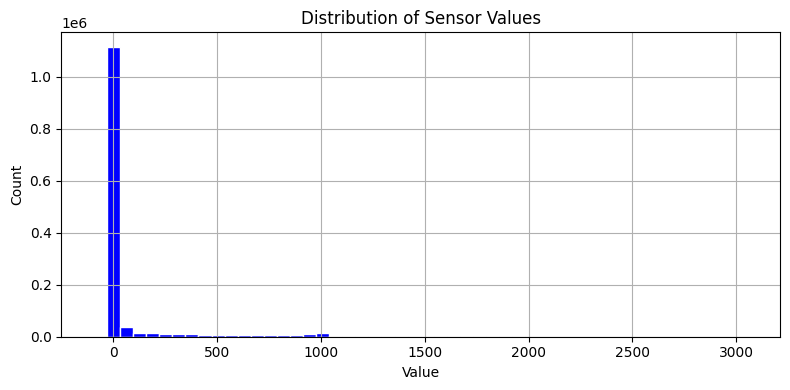


Number of Values with |z| > 3: 47378
Percentage: 0.0359

Outliers per measure type (|z| > 3):
measure
ws02              1849
ws06              1221
blackglobetemp     248
sr                 214
temp_wxt           143
temp10             142
par                126
ws10                54
precip              17
sm                  17
st                   9
pres                 5
leafwetness          4
dtype: int64


In [ ]:
# EDA

# value distribution
plt.figure(figsize=(8, 4))
df_sample['value'].hist(bins=50, color='blue', edgecolor='white')
plt.title('Distribution of Sensor Values')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# check for outliers w z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df_sample['value'].dropna()))

print(f"\nNumber of Values with |z| > 3: {(z_scores > 3).sum()}")
print(f"Percentage: {(z_scores > 3).mean():.4f}")

# z-score computed per measure type
df_sample['value_zscore'] = df_sample.groupby('measure')['value'].transform(
    lambda x: np.abs((x - x.mean()) / x.std())
)

print(f"\nOutliers per measure type (|z| > 3):")
print(df_sample[df_sample['value_zscore'] > 3].groupby('measure').size().sort_values(ascending=False))

The cell below shows us skewness of all the different measurements. This will be helpful for determining if we need to do any transformations (e.g. log) on our numeric data. Anything with a greater than 1 or less than - 1 has a signifcant skew, and we will consider applying transformations to them.

We also look at correlations between the measurements and target feature. There is actually a really big surprise of a 0.95 correlation between rh_hmp and the target feature being an erroneous reading.

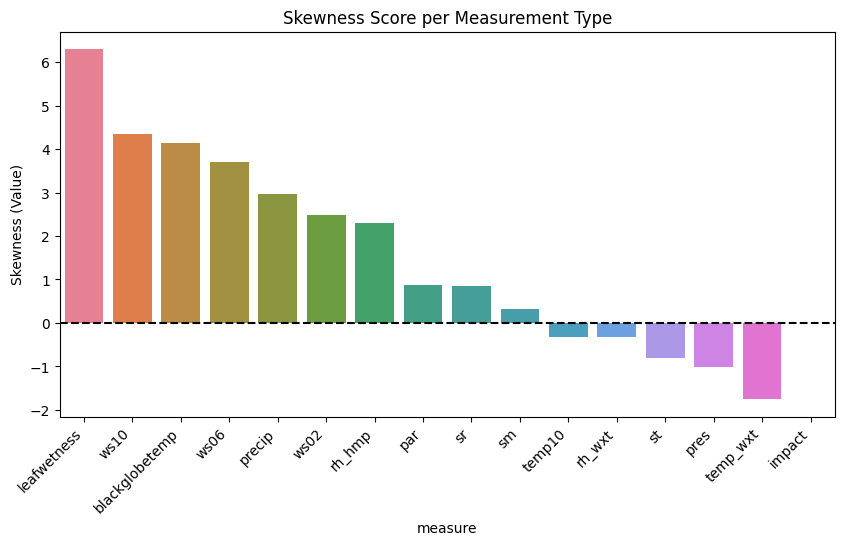

           measure  skewness_score
0      leafwetness        6.301518
1             ws10        4.344124
2   blackglobetemp        4.138451
3             ws06        3.712539
4           precip        2.964587
5             ws02        2.477653
6           rh_hmp        2.287783
7              par        0.862009
8               sr        0.854324
9               sm        0.317037
10          temp10       -0.313937
11          rh_wxt       -0.323483
12              st       -0.816028
13            pres       -1.024930
14        temp_wxt       -1.751483
15          impact             NaN


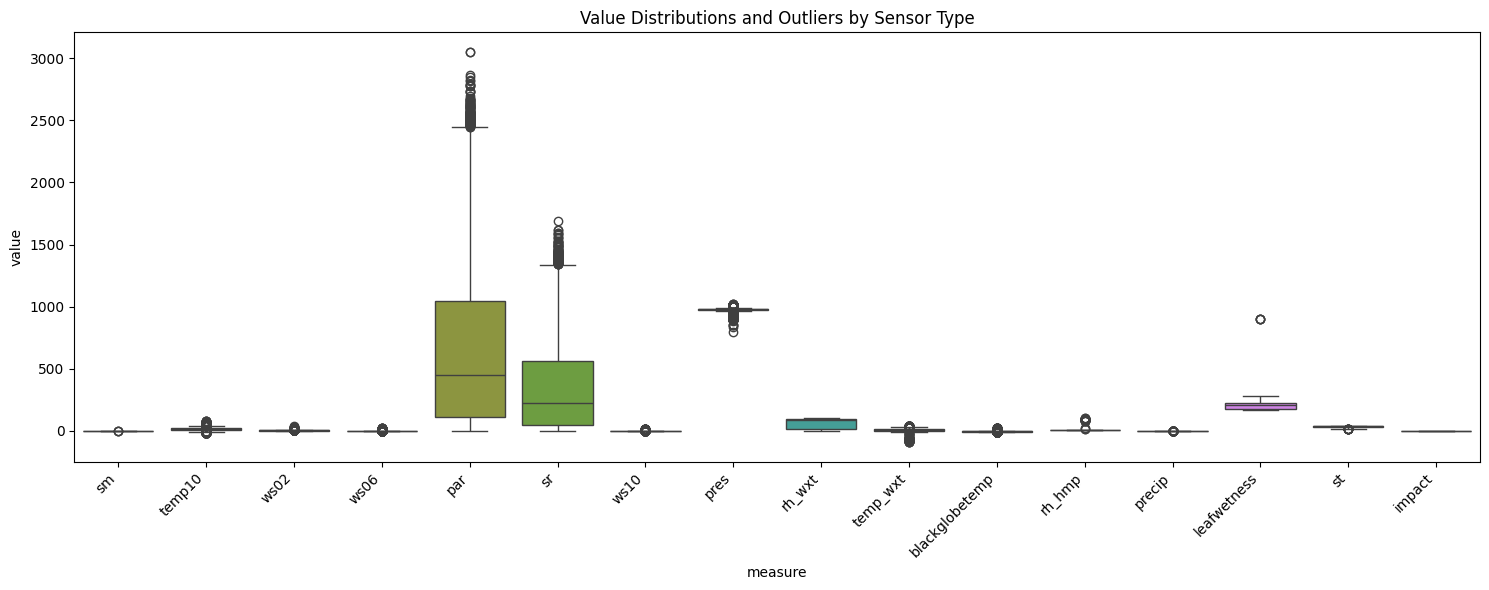


Correlation of sensor values with 'True Error' target:
           measure  correlation_with_error
11          rh_hmp                0.946892
10  blackglobetemp                0.810144
0               sm                0.161569
8           rh_wxt                0.118858
1           temp10                0.060036
13     leafwetness                0.000000
14              st                0.000000
15          impact                0.000000
4              par               -0.028818
7             pres               -0.055450
5               sr               -0.055741
3             ws06               -0.066898
2             ws02               -0.126712
9         temp_wxt               -0.129164
12          precip               -0.446883
6             ws10               -0.869773


In [ ]:
# --- IMPROVED GROUPED EDA ---

# 1. Grouped Skewness: Identifying which sensors have 'long tails'
# We calculate skew on the 'value' column but grouped by 'measure'
measure_skew = df_sample.groupby('measure')['value'].skew().sort_values(ascending=False).reset_index()
measure_skew.columns = ['measure', 'skewness_score']

# 2. Visualizing Skewness
plt.figure(figsize=(10, 5))
sns.barplot(data=measure_skew, x='measure', y='skewness_score', hue='measure', legend=False)
plt.axhline(0, color='black', linestyle='--')
plt.title('Skewness Score per Measurement Type')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Skewness (Value)')
plt.show()
print(measure_skew)

# 3. Grouped Boxplots: Seeing outliers for each sensor type
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_sample, x='measure', y='value', hue='measure', legend=False)
plt.title('Value Distributions and Outliers by Sensor Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Measure-Specific Correlation
# This shows which sensor values are most likely to be 'True Errors'
df_sample['target_numeric'] = df_sample['target'].astype(int)
grouped_corr = []

for measure in df_sample['measure'].unique():
    subset = df_sample[df_sample['measure'] == measure]
    if subset['target_numeric'].nunique() > 1:
        corr = subset[['value', 'target_numeric']].corr().iloc[0, 1]
    else:
        corr = 0
    grouped_corr.append({'measure': measure, 'correlation_with_error': corr})

corr_df = pd.DataFrame(grouped_corr).sort_values('correlation_with_error', ascending=False)
print("\nCorrelation of sensor values with 'True Error' target:")
print(corr_df)

Outlier count for value per measure (z-score > 3)
  blackglobetemp             248 outliers  (2.67%)
  leafwetness                  4 outliers  (2.06%)
  par                        126 outliers  (0.12%)
  precip                      17 outliers  (3.06%)
  pres                         5 outliers  (0.03%)
  sm                          17 outliers  (0.00%)
  sr                         214 outliers  (0.20%)
  st                           9 outliers  (0.59%)
  temp10                     142 outliers  (0.09%)
  temp_wxt                   143 outliers  (0.57%)
  ws02                     1,849 outliers  (1.84%)
  ws06                     1,221 outliers  (3.58%)
  ws10                        54 outliers  (3.84%)

Outlier count for flag columns (z-score > 3)
  R_flag          68,146 outliers  (5.17%)
  I_flag          42,636 outliers  (3.23%)
  Z_flag          48,605 outliers  (3.69%)
  B_flag               4 outliers  (0.00%)


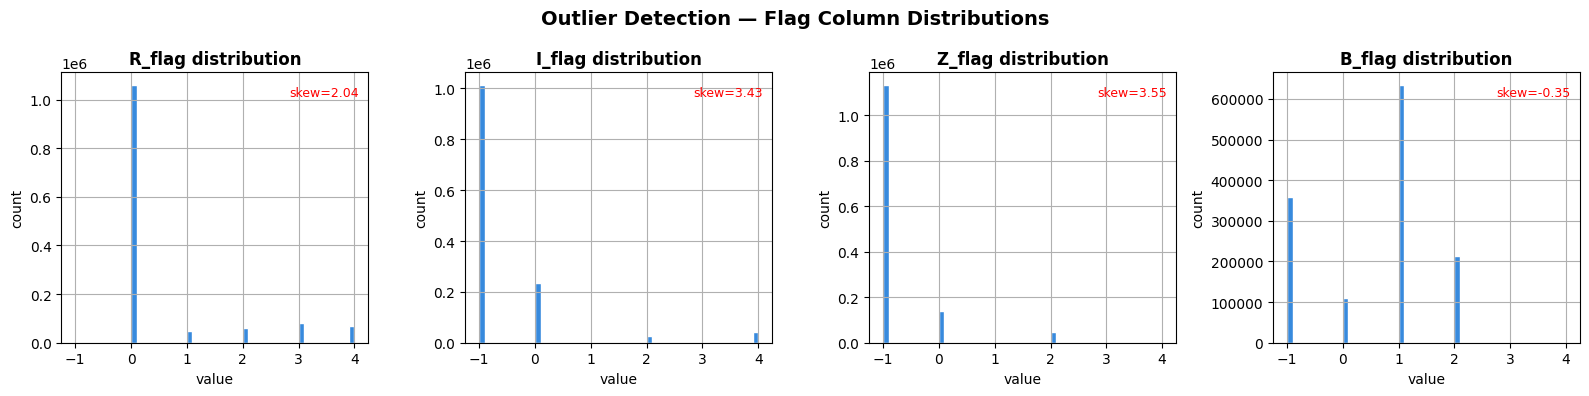

In [ ]:
#Outlier Detection: Z-Score Analysis
from scipy import stats

original_cols = ["value", "R_flag", "I_flag", "Z_flag", "B_flag"]

# compute z-scores per measure for value column
df_sample['value_zscore'] = df_sample.groupby('measure')['value'].transform(
    lambda x: np.abs((x - x.mean()) / x.std())
)

# compute overall z-scores for flag columns
z_scores = df_sample[["R_flag", "I_flag", "Z_flag", "B_flag"]].apply(stats.zscore)

# count outliers for value per measure
print("Outlier count for value per measure (z-score > 3)")
outlier_tbl = df_sample[df_sample['value_zscore'] > 3].groupby('measure').size()
for measure, count in outlier_tbl.items():
    pct = count / len(df_sample[df_sample['measure'] == measure]) * 100
    print(f"  {measure:20s}  {count:>8,} outliers  ({pct:.2f}%)")

# count outliers for flag columns
print("\nOutlier count for flag columns (z-score > 3)")
for col in ["R_flag", "I_flag", "Z_flag", "B_flag"]:
    n_outliers = (np.abs(z_scores[col]) > 3).sum()
    pct = n_outliers / len(df_sample) * 100
    print(f"  {col:10s}  {n_outliers:>10,} outliers  ({pct:.2f}%)")



# histograms for flag columns
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Outlier Detection — Flag Column Distributions", fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["R_flag", "I_flag", "Z_flag", "B_flag"]):
    df_sample[col].hist(bins=50, ax=ax, color="#378ADD", edgecolor="white")
    ax.set_title(f"{col} distribution", fontweight="bold")
    ax.set_xlabel("value")
    ax.set_ylabel("count")
    skew = df_sample[col].skew()
    ax.annotate(f"skew={skew:.2f}", xy=(0.97, 0.95),
                xycoords="axes fraction", ha="right", va="top",
                fontsize=9, color="red")

plt.tight_layout()
plt.savefig("outlier_histograms.png", bbox_inches="tight", dpi=150)
plt.show()

## Outlier Detection: Z-Score Analysis
The z-score outlier analysis using a threshold of 3 standard deviations computed per measure reveals that outlier rates vary significantly across the 13 sensor types. Wind speed sensors are the most problematic with ws10 having the highest outlier rate at 3.84% (54 outliers), followed by ws06 at 3.58% (1,221 outliers) and ws02 at 1.84% (1,849 outliers) — suggesting wind sensors frequently produce extreme readings relative to their normal operating range. precip follows at 3.06% (17 outliers) and blackglobetemp at 2.67% (248 outliers). At the other extreme sm has virtually zero outliers (0.00%) despite being the largest measure by volume, and pres has only 5 outliers (0.03%) confirming these two sensors are extremely stable. For the flag columns R_flag has the highest outlier count at 68,146 (5.17%) followed by Z_flag at 48,605 (3.69%) and I_flag at 42,636 (3.23%) — these flag outliers represent genuine predictive signals and must be preserved rather than removed. B_flag has virtually no outliers at just 4 rows (0.00%) making it the most stable flag column in the dataset.

In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_recall_curve, auc
from sklearn.impute import SimpleImputer

# --- 1. GLOBAL SETTINGS & DATA SPLIT ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Convert target to int (0/1)
df['target_int'] = df['target'].astype(int)
X = df.drop(columns=['target', 'target_int'])
y = df['target_int']

# 80/20 Split: X_train is for Cross-Validation, X_test is the "Final Exam"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Training/CV size: {X_train.shape} | {y_train.mean():.4f} positive rate")
print(f"Final Test size:  {X_test.shape} | {y_test.mean():.4f} positive rate")

Training/CV size: (5274619, 8) | 0.0357 positive rate
Final Test size:  (1318655, 8) | 0.0357 positive rate


The data is split using an 80/20 stratified split on the full 6,593,274 row dataset. The 80% training set (5,274,619 rows) is reserved for model training and cross-validation while the 20% test set (1,318,655 rows) serves as the final holdout for evaluating model performance. Stratification ensures that the original class distribution of 3.57% true errors and 96.43% false positives is preserved identically in both splits. Rather than using a fixed validation set this approach relies on k-fold cross-validation applied

In [ ]:
# --- 2. Custom Transformers ---

class GroupedScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stats_ = None
        self.global_mean_ = 0

    def fit(self, X, y=None):
        # 1. Calculate stats per group
        self.stats_ = X.groupby('measure')['value'].agg(['mean', 'std'])
        # 2. Safety: Calculate a global mean if a group is missing entirely
        self.global_mean_ = X['value'].mean()
        return self

    def transform(self, X):
        X_out = X[['value', 'measure']].copy()
        # Map means/stds. fillna(1) prevents the "Divide by Zero/NaN" error
        means = X_out['measure'].map(self.stats_['mean']).fillna(self.global_mean_)
        stds = X_out['measure'].map(self.stats_['std']).fillna(1).replace(0, 1)

        X_out['value'] = (X_out['value'] - means) / stds
        # Final safety: If the input was NaN, set it to 0 (the new mean)
        X_out['value'] = X_out['value'].fillna(0)
        return X_out[['value']]

def mia_flag_logic(X):
    X_df = pd.DataFrame(X)
    X_out = pd.DataFrame(index=X_df.index)

    for i, col in enumerate(X_df.columns):
        # 1. Indicator: 1 if it ISN'T -1 (it ran), 0 if it IS -1 (didn't run)
        X_out[f'flag_{i}_was_run'] = (X_df[col] != -1).astype(int)

        # 2. Score: Replace the -1s with 0s
        X_out[f'flag_{i}_score'] = X_df[col].replace(-1, 0)

    return X_out

We used custom transformer that standardizes the value column per measure group rather than across the entire dataset. This is necessary because value represents fundamentally different physical quantities depending on the measure a value of 13 means something completely different for temp_wxt (temperature in Celsius) versus sm (soil moisture between 0 and 1)  making a global scaling approach misleading and potentially harmful to model performance. The scaler works by first computing the mean and standard deviation for each measure group during the fit step on the training data only, then applying the standard z-score formula (value - measure_mean) / measure_std during the transform step. Several safety features are built in to handle edge cases  a global mean is used as a fallback for any unseen measures in the test data, division by zero is prevented by replacing zero standard deviations with 1, and any remaining NaN values are filled with 0 representing the new scaled mean. By implementing this as a sklearn compatible transformer using BaseEstimator and TransformerMixin it can be safely integrated into a preprocessing pipeline where it is fit on training data only and applied consistently to validation and test data, preventing data leakage.

In [ ]:
# --- 3. THE PIPELINE ARCHITECTURE ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num_grouped', GroupedScaler(), ['value', 'measure']),
        ('flags_mia', FunctionTransformer(mia_flag_logic),
         ['R_flag', 'I_flag', 'Z_flag', 'B_flag']),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True),
         ['Station', 'measure'])
    ],
    sparse_threshold=0
)

def get_pipe(model):
    """Binds the preprocessor to a model into one memory-efficient object."""
    return Pipeline([
        ('preprocessor', preprocessor),
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('classifier', model)
    ])

In [ ]:

# Pipeline 2 — With Time Features (hour and month)

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

# extract time features from Ob before pipeline
for dataset in [X_train, X_test]:
    dataset['hour']  = pd.to_datetime(dataset['Ob']).dt.hour
    dataset['month'] = pd.to_datetime(dataset['Ob']).dt.month

print("Time features added successfully")
print(f"  hour  — range: {X_train['hour'].min()} to {X_train['hour'].max()}")
print(f"  month — range: {X_train['month'].min()} to {X_train['month'].max()}")

# build preprocessor 2 — with time features
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num_grouped', GroupedScaler(),
         ['value', 'measure']),
        ('flags_mia', FunctionTransformer(mia_flag_logic),
         ['R_flag', 'I_flag', 'Z_flag', 'B_flag']),
        ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True),
         ['Station', 'measure']),
        ('time_features', 'passthrough',
         ['hour', 'month'])
    ],
    sparse_threshold=0
)

def get_pipe_2(model):
    """Binds preprocessor 2 to a model — includes time features."""
    return Pipeline([
        ('preprocessor', preprocessor_2),
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('classifier', model)
    ])


Time features added successfully
  hour  — range: 0 to 23
  month — range: 1 to 12


In [ ]:
# --- THE SMOKE TEST ---
# 1. Take a 50,000 sample to test the workflow
X_smoke = X_train.head(50_000)
y_smoke = y_train.head(50_000)

print("-------- STARTING SMOKE TEST --------")

# 2. Test the KNN Pipeline (The most 'sensitive' one)
test_pipe = get_pipe(KNeighborsClassifier(n_jobs=-1))

try:
    # Fit the pipeline
    test_pipe.fit(X_smoke, y_smoke)

    # Predict to ensure transform works on 'new' data
    dummy_pred = test_pipe.predict(X_smoke)

    print("YUH SUCCESS: The Pipeline is healthy!")
    print(f"Processed {X_smoke.shape[1]} columns into {test_pipe.named_steps['preprocessor'].transform(X_smoke).shape[1]} features.")

except Exception as e:
    print("NOOOOOOO ERROR in Pipeline:")
    print(e)

# test Pipeline 2 — with time features
print("\nTesting Pipeline 2 — with time features...")
test_pipe_2 = get_pipe_2(KNeighborsClassifier(n_jobs=-1))

try:
    test_pipe_2.fit(X_smoke, y_smoke)
    dummy_pred = test_pipe_2.predict(X_smoke)
    n_features = test_pipe_2.named_steps['preprocessor'].transform(X_smoke).shape[1]
    print(f"SUCCESS — Pipeline 2 is healthy!")
    print(f"  Input columns  : {X_smoke.shape[1]}")
    print(f"  Output features: {n_features}")
except Exception as e:
    print(f"ERROR in Pipeline 2: {e}")


-------- STARTING SMOKE TEST --------
YUH SUCCESS: The Pipeline is healthy!
Processed 10 columns into 67 features.

Testing Pipeline 2 — with time features...
SUCCESS — Pipeline 2 is healthy!
  Input columns  : 10
  Output features: 69


In [ ]:
# --- 4. CROSS-VALIDATION EXECUTION ---

# Define metrics for CV (focusing on Imbalanced Data needs)
def pr_auc_score(y_true, y_probs):
    prec, rec, _ = precision_recall_curve(y_true, y_probs)
    return auc(rec, prec)

scoring = {
    'f1': 'f1',
    'recall': 'recall',
    'pr_auc': make_scorer(pr_auc_score, response_method='predict_proba')
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=SEED),  # <-- add comma here
    "Logistic Regression (Lasso)": LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED
    )
}

print("\nStarting Cross-Validation...")
cv_results = {}

for name, model_obj in models.items():
    print(f"Starting {name}...")
    pipe = get_pipe(model_obj)
    # verbose=2 will print out each fold as it completes
    # scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, verbose=2)
    scores = cross_validate(pipe, X_smoke, y_smoke, cv=skf, scoring=scoring, verbose=2)


    cv_results[name] = {
        'F1': scores['test_f1'].mean(),
        'Recall': scores['test_recall'].mean(),
        'PR-AUC': scores['test_pr_auc'].mean()
    }
    print(f"✅ {name} CV Complete")


Starting Cross-Validation...
Starting KNN...
[CV] END .................................................... total time=   7.6s
[CV] END .................................................... total time=  10.0s
[CV] END .................................................... total time=   8.8s
[CV] END .................................................... total time=   8.8s
[CV] END .................................................... total time=   9.9s
✅ KNN CV Complete
Starting Decision Tree...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   45.1s finished


[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
✅ Decision Tree CV Complete
Starting Random Forest...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    1.6s finished


[CV] END .................................................... total time=   3.4s
[CV] END .................................................... total time=   4.7s
[CV] END .................................................... total time=   5.9s
[CV] END .................................................... total time=   3.4s
[CV] END .................................................... total time=   3.5s
✅ Random Forest CV Complete
Starting Logistic Regression (Lasso)...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   20.8s finished


[CV] END .................................................... total time=   1.5s
[CV] END .................................................... total time=   2.2s
[CV] END .................................................... total time=   6.1s
[CV] END .................................................... total time=   4.0s
[CV] END .................................................... total time=   6.8s
✅ Logistic Regression (Lasso) CV Complete


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   20.6s finished


In [ ]:
# --- 4b. CROSS-VALIDATION EXECUTION — PIPELINE 2 ---

print("\nStarting Cross-Validation — Pipeline 2 (with time features)...")
cv_results_pipe2 = {}

for name, model_obj in models.items():
    print(f"Starting {name}...")
    pipe = get_pipe_2(model_obj)
    scores = cross_validate(pipe, X_smoke, y_smoke, cv=skf, scoring=scoring, verbose=2)
    cv_results_pipe2[name] = {
        'F1'    : scores['test_f1'].mean(),
        'Recall': scores['test_recall'].mean(),
        'PR-AUC': scores['test_pr_auc'].mean()
    }
    print(f"✅ {name} Pipeline 2 CV Complete")


Starting Cross-Validation — Pipeline 2 (with time features)...
Starting KNN...
[CV] END .................................................... total time=   8.1s
[CV] END .................................................... total time=  10.1s
[CV] END .................................................... total time=   7.7s
[CV] END .................................................... total time=  10.0s
[CV] END .................................................... total time=   9.4s
✅ KNN Pipeline 2 CV Complete
Starting Decision Tree...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   45.4s finished


[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
✅ Decision Tree Pipeline 2 CV Complete
Starting Random Forest...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.1s finished


[CV] END .................................................... total time=   3.3s
[CV] END .................................................... total time=   3.4s
[CV] END .................................................... total time=   3.9s
[CV] END .................................................... total time=   5.0s
[CV] END .................................................... total time=   3.3s
✅ Random Forest Pipeline 2 CV Complete
Starting Logistic Regression (Lasso)...


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   18.9s finished


[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   4.7s
[CV] END .................................................... total time=   7.2s
✅ Logistic Regression (Lasso) Pipeline 2 CV Complete


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   19.0s finished


In [ ]:
# --- LASSO HYPERPARAMETER TUNING ---
from sklearn.model_selection import GridSearchCV

print("Starting GridSearchCV for Logistic Regression (Lasso)...")

# Base pipeline with a placeholder LR model
lr_base = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED
)

lr_pipe = get_pipe(lr_base)

# C grid from the design doc: log-scaled from very strong to very weak regularization
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid,
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=2
)

lr_grid_search.fit(X_smoke, y_smoke)

# Results
print(f"\n✅ Best C value : {lr_grid_search.best_params_['classifier__C']}")
print(f" Best CV F1 : {lr_grid_search.best_score_:.4f}")

# Full results table
lr_cv_results = pd.DataFrame(lr_grid_search.cv_results_)
print("\nFull C grid results:")
print(
    lr_cv_results[['param_classifier__C', 'mean_test_score','std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .round(4)
    .to_string(index=False)
)

Starting GridSearchCV for Logistic Regression (Lasso)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Best C value : 100.0
 Best CV F1 : 0.4566

Full C grid results:
 param_classifier__C  mean_test_score  std_test_score
             100.000           0.4566          0.0093
              10.000           0.4566          0.0092
               1.000           0.4518          0.0076
               0.100           0.4353          0.0121
               0.010           0.3313          0.0110
               0.001           0.2047          0.0064


In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# KNN HYPERPARAMETER TUNING
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\nStarting GridSearchCV for KNN...")

knn_pipe = get_pipe(KNeighborsClassifier(n_jobs=-1))

knn_grid_search = GridSearchCV(
    estimator=knn_pipe,
    param_grid={
        'classifier__n_neighbors': [3, 5, 11, 21],
        'classifier__weights':     ['uniform', 'distance'],
        'classifier__metric':      ['euclidean', 'manhattan'],
    },
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=2
)

knn_grid_search.fit(X_smoke, y_smoke)

print(f"\n✅ KNN Best params : {knn_grid_search.best_params_}")
print(f"   KNN Best CV F1  : {knn_grid_search.best_score_:.4f}")

knn_cv_results = pd.DataFrame(knn_grid_search.cv_results_)
print("\nFull KNN grid results:")
print(
    knn_cv_results[['param_classifier__n_neighbors',
                    'param_classifier__weights',
                    'param_classifier__metric',
                    'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .round(4)
    .to_string(index=False)
)


Starting GridSearchCV for KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ KNN Best params : {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
   KNN Best CV F1  : 0.8860

Full KNN grid results:
 param_classifier__n_neighbors param_classifier__weights param_classifier__metric  mean_test_score  std_test_score
                            11                  distance                manhattan           0.8860          0.0108
                             5                  distance                manhattan           0.8839          0.0164
                            11                  distance                euclidean           0.8834          0.0106
                            21                  distance                manhattan           0.8824          0.0086
                             5                  distance                euclidean           0.8819          0.0162
                            21          

In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# DECISION TREE HYPERPARAMETER TUNING
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\nStarting GridSearchCV for Decision Tree...")

dt_pipe = get_pipe(DecisionTreeClassifier(class_weight='balanced', random_state=SEED))

dt_grid_search = GridSearchCV(
    estimator=dt_pipe,
    param_grid={
        'classifier__max_depth':        [3, 5, 10, None],
        'classifier__min_samples_leaf': [1, 5, 20, 50],
        'classifier__criterion':        ['gini', 'entropy'],
    },
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=2
)

dt_grid_search.fit(X_smoke, y_smoke)

print(f"\n✅ DT Best params : {dt_grid_search.best_params_}")
print(f"   DT Best CV F1  : {dt_grid_search.best_score_:.4f}")

dt_cv_results = pd.DataFrame(dt_grid_search.cv_results_)
print("\nFull DT grid results:")
print(
    dt_cv_results[['param_classifier__max_depth',
                   'param_classifier__min_samples_leaf',
                   'param_classifier__criterion',
                   'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .round(4)
    .to_string(index=False)
)


Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ DT Best params : {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1}
   DT Best CV F1  : 0.8665

Full DT grid results:
param_classifier__max_depth  param_classifier__min_samples_leaf param_classifier__criterion  mean_test_score  std_test_score
                       None                                   1                     entropy           0.8665          0.0086
                       None                                   1                        gini           0.8637          0.0044
                       None                                   5                     entropy           0.7919          0.0061
                       None                                   5                        gini           0.7839          0.0157
                         10                                   1                     entropy     

In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# RANDOM FOREST HYPERPARAMETER TUNING
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\nStarting GridSearchCV for Random Forest...")

rf_pipe = get_pipe(RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=SEED))

rf_grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid={
        'classifier__n_estimators':     [100, 300],
        'classifier__max_depth':        [5, 10, None],
        'classifier__min_samples_leaf': [1, 10, 50],
    },
    cv=skf,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=2
)

rf_grid_search.fit(X_smoke, y_smoke)

print(f"\n✅ RF Best params : {rf_grid_search.best_params_}")
print(f"   RF Best CV F1  : {rf_grid_search.best_score_:.4f}")

rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)
print("\nFull RF grid results:")
print(
    rf_cv_results[['param_classifier__n_estimators',
                   'param_classifier__max_depth',
                   'param_classifier__min_samples_leaf',
                   'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .round(4)
    .to_string(index=False)
)


Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ RF Best params : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
   RF Best CV F1  : 0.8825

Full RF grid results:
 param_classifier__n_estimators param_classifier__max_depth  param_classifier__min_samples_leaf  mean_test_score  std_test_score
                            100                        None                                   1           0.8825          0.0094
                            300                        None                                   1           0.8817          0.0084
                            300                        None                                  10           0.7332          0.0275
                            100                        None                                  10           0.7263          0.0311
                            300                          10                     

In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# HP TUNING SUMMARY TABLE
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\n========== HYPERPARAMETER TUNING SUMMARY ==========")
hp_summary = pd.DataFrame([
    {'Model': 'Lasso (LR)',      'Best Params': str(lr_grid_search.best_params_),  'CV F1': lr_grid_search.best_score_},
    {'Model': 'KNN',             'Best Params': str(knn_grid_search.best_params_), 'CV F1': knn_grid_search.best_score_},
    {'Model': 'Decision Tree',   'Best Params': str(dt_grid_search.best_params_),  'CV F1': dt_grid_search.best_score_},
    {'Model': 'Random Forest',   'Best Params': str(rf_grid_search.best_params_),  'CV F1': rf_grid_search.best_score_},
])
hp_summary['CV F1'] = hp_summary['CV F1'].round(4)
print(hp_summary.to_string(index=False))


========== HYPERPARAMETER TUNING SUMMARY ==========
        Model                                                                                            Best Params  CV F1
   Lasso (LR)                                                                               {'classifier__C': 100.0} 0.4566
          KNN  {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'} 0.8860
Decision Tree {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1} 0.8665
Random Forest    {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100} 0.8825


In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# PIPELINE 2 HYPERPARAMETER TUNING (With Time Features)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("\n--- Starting HP Tuning for Pipeline 2 (Engineered Features) ---")

# 1. Lasso P2
lr_pipe_p2 = get_pipe_2(LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1000, random_state=SEED))
lr_grid_p2 = GridSearchCV(estimator=lr_pipe_p2, param_grid={'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0]}, cv=skf, scoring='f1', n_jobs=-1)
lr_grid_p2.fit(X_smoke, y_smoke)

# 2. KNN P2
knn_pipe_p2 = get_pipe_2(KNeighborsClassifier(n_jobs=-1))
knn_grid_p2 = GridSearchCV(estimator=knn_pipe_p2, param_grid={'classifier__n_neighbors': [5, 11, 21], 'classifier__weights': ['uniform', 'distance']}, cv=skf, scoring='f1', n_jobs=-1)
knn_grid_p2.fit(X_smoke, y_smoke)

# 3. Decision Tree P2
dt_pipe_p2 = get_pipe_2(DecisionTreeClassifier(class_weight='balanced', random_state=SEED))
dt_grid_p2 = GridSearchCV(estimator=dt_pipe_p2, param_grid={'classifier__max_depth': [5, 10, None], 'classifier__min_samples_leaf': [5, 20]}, cv=skf, scoring='f1', n_jobs=-1)
dt_grid_p2.fit(X_smoke, y_smoke)

# 4. Random Forest P2
rf_pipe_p2 = get_pipe_2(RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=SEED))
rf_grid_p2 = GridSearchCV(estimator=rf_pipe_p2, param_grid={'classifier__n_estimators': [100, 300], 'classifier__max_depth': [10, None]}, cv=skf, scoring='f1', n_jobs=-1)
rf_grid_p2.fit(X_smoke, y_smoke)

print("✅ Pipeline 2 Tuning Complete.")


--- Starting HP Tuning for Pipeline 2 (Engineered Features) ---
✅ Pipeline 2 Tuning Complete.


In [ ]:
# --- 5. COMPARISON TABLE ---
results_df = pd.DataFrame(cv_results).T
print("\nFinal Model Comparison (CV Results):")
print(results_df.round(4))


Final Model Comparison (CV Results):
                                 F1  Recall  PR-AUC
KNN                          0.8730  0.8439  0.9357
Decision Tree                0.4340  0.8969  0.7483
Random Forest                0.8825  0.8924  0.9462
Logistic Regression (Lasso)  0.4518  0.9510  0.4938


In [ ]:
# --- 5. COMPARISON TABLE ---

# Pipeline 1 results
results_pipe1 = pd.DataFrame(cv_results).T
results_pipe1.columns = ['P1 F1', 'P1 Recall', 'P1 PR-AUC']

# Pipeline 2 results
results_pipe2 = pd.DataFrame(cv_results_pipe2).T
results_pipe2.columns = ['P2 F1', 'P2 Recall', 'P2 PR-AUC']

# combine both into one table
comparison = pd.concat([results_pipe1, results_pipe2], axis=1)


print("Pipeline 1 vs Pipeline 2 — CV Results Comparison")

print(comparison.round(4))

# show improvement from Pipeline 1 to Pipeline 2
print("\n--- Improvement from Pipeline 1 to Pipeline 2 ---")
comparison['F1 change']     = (comparison['P2 F1']     - comparison['P1 F1']).round(4)
comparison['PR-AUC change'] = (comparison['P2 PR-AUC'] - comparison['P1 PR-AUC']).round(4)
print(comparison[['F1 change', 'PR-AUC change']])

Pipeline 1 vs Pipeline 2 — CV Results Comparison
                              P1 F1  P1 Recall  P1 PR-AUC   P2 F1  P2 Recall  \
KNN                          0.8730     0.8439     0.9357  0.8376     0.7921   
Decision Tree                0.4340     0.8969     0.7483  0.3872     0.9301   
Random Forest                0.8825     0.8924     0.9462  0.9282     0.8969   
Logistic Regression (Lasso)  0.4518     0.9510     0.4938  0.5168     0.9555   

                             P2 PR-AUC  
KNN                             0.9088  
Decision Tree                   0.6965  
Random Forest                   0.9768  
Logistic Regression (Lasso)     0.5605  

--- Improvement from Pipeline 1 to Pipeline 2 ---
                             F1 change  PR-AUC change
KNN                            -0.0354        -0.0269
Decision Tree                  -0.0468        -0.0517
Random Forest                   0.0458         0.0305
Logistic Regression (Lasso)     0.0650         0.0667


In [ ]:
# --- FINAL TUNED COMPARISON ---
hp_comparison = pd.DataFrame([
    {'Model': 'Lasso (LR)',    'P1 Best F1': lr_grid_search.best_score_, 'P2 Best F1': lr_grid_p2.best_score_},
    {'Model': 'KNN',           'P1 Best F1': knn_grid_search.best_score_, 'P2 Best F1': knn_grid_p2.best_score_},
    {'Model': 'Decision Tree', 'P1 Best F1': dt_grid_search.best_score_, 'P2 Best F1': dt_grid_p2.best_score_},
    {'Model': 'Random Forest', 'P1 Best F1': rf_grid_search.best_score_, 'P2 Best F1': rf_grid_p2.best_score_},
])

hp_comparison['Improvement'] = hp_comparison['P2 Best F1'] - hp_comparison['P1 Best F1']
hp_comparison['Winner'] = np.where(hp_comparison['Improvement'] > 0, 'Pipeline 2', 'Pipeline 1')

print("\n========== FINAL TUNED MODEL COMPARISON ==========")
print(hp_comparison.round(4).to_string(index=False))

# Calculate Overall Winner
best_overall_f1 = hp_comparison[['P1 Best F1', 'P2 Best F1']].max().max()
print(f"\n🏆 Best Overall Model F1 Score: {best_overall_f1:.4f}")


========== FINAL TUNED MODEL COMPARISON ==========
        Model  P1 Best F1  P2 Best F1  Improvement     Winner
   Lasso (LR)      0.4566      0.5176       0.0610 Pipeline 2
          KNN      0.8860      0.8619      -0.0241 Pipeline 1
Decision Tree      0.8665      0.8374      -0.0291 Pipeline 1
Random Forest      0.8825      0.9298       0.0473 Pipeline 2

🏆 Best Overall Model F1 Score: 0.9298


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# filter SPRU with selected measures
selected_measures = ['temp10', 'ws02', 'ws06', 'ws10']
mask = (df['Station'] == 'SPRU') & (df['measure'].isin(selected_measures))

df_spru = df[mask].copy()

# sort by timestamp
df_spru = df_spru.sort_values('Ob').reset_index(drop=True)

# extract time features
df_spru['hour']  = pd.to_datetime(df_spru['Ob']).dt.hour
df_spru['month'] = pd.to_datetime(df_spru['Ob']).dt.month

# handle -1 in flag columns
for col in ['R_flag', 'I_flag', 'Z_flag', 'B_flag']:
    df_spru[f'{col}_was_run'] = (df_spru[col] != -1).astype(int)
    df_spru[col] = df_spru[col].replace(-1, 0)

# label encode measure
le = LabelEncoder()
df_spru['measure_encoded'] = le.fit_transform(df_spru['measure'])

# scale value per measure group
df_spru['value_scaled'] = df_spru.groupby('measure')['value'].transform(
    lambda x: (x - x.mean()) / (x.std() if x.std() != 0 else 1)
)

# define feature columns
feature_cols = [
    'value_scaled',
    'R_flag', 'I_flag', 'Z_flag', 'B_flag',
    'R_flag_was_run', 'I_flag_was_run', 'Z_flag_was_run', 'B_flag_was_run',
    'hour', 'month',
    'measure_encoded'
]

print(f"df_spru recreated successfully")
print(f"Shape : {df_spru.shape}")
print(f"Features : {feature_cols}")

df_spru recreated successfully
Shape : (97502, 18)
Features : ['value_scaled', 'R_flag', 'I_flag', 'Z_flag', 'B_flag', 'R_flag_was_run', 'I_flag_was_run', 'Z_flag_was_run', 'B_flag_was_run', 'hour', 'month', 'measure_encoded']


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# create sliding window sequences
def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
      # window of past readings
        Xs.append(X[i:i+window_size])
        # predict current reading
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

# prepare features and target
X_arr = df_spru[feature_cols].values.astype(np.float32)
y_arr = df_spru['target'].astype(int).values

# create sequences with window of 10
WINDOW_SIZE = 10
X_seq, y_seq = create_sequences(X_arr, y_arr, WINDOW_SIZE)

print(f"X_seq shape : {X_seq.shape}")
print(f"y_seq shape : {y_seq.shape}")
print(f"True errors : {y_seq.sum():,}")
print(f"Error rate  : {y_seq.mean():.4f}")

X_seq shape : (97492, 10, 12)
y_seq shape : (97492,)
True errors : 88,289
Error rate  : 0.9056


In [ ]:
# first split — 80% train+val, 20% test
X_temp, X_test_seq, y_temp, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.20,
    stratify=y_seq,
    random_state=SEED
)

# second split — 75% train, 25% val
X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=SEED
)

print(f"Train shape : {X_train_seq.shape} | error rate: {y_train_seq.mean():.4f}")
print(f"Val shape   : {X_val_seq.shape}   | error rate: {y_val_seq.mean():.4f}")
print(f"Test shape  : {X_test_seq.shape}  | error rate: {y_test_seq.mean():.4f}")

Train shape : (58494, 10, 12) | error rate: 0.9056
Val shape   : (19499, 10, 12)   | error rate: 0.9056
Test shape  : (19499, 10, 12)  | error rate: 0.9056


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# set random seed for reproducibility
tf.random.set_seed(SEED)

# build LSTM model
model = Sequential([
    # first LSTM layer
    LSTM(64, input_shape=(WINDOW_SIZE, len(feature_cols)),
         return_sequences=True),
    Dropout(0.2),           # prevents overfitting

    # second LSTM layer
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # dense layers
    Dense(16, activation='relu'),
    BatchNormalization(),   # stabilizes training

    # output layer — sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,737 (127.88 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 32 (128.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_seq),
    y=y_train_seq
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# train the model
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=256,
    validation_data=(X_val_seq, y_val_seq),
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

print("Training complete!")

Class weights: {0: np.float64(5.297409889512769), 1: np.float64(0.5521114530043607)}
Epoch 1/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8206 - loss: 0.3385 - val_accuracy: 0.9280 - val_loss: 0.1871
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.8924 - loss: 0.2424 - val_accuracy: 0.9080 - val_loss: 0.1897
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8963 - loss: 0.2288 - val_accuracy: 0.9051 - val_loss: 0.2059
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9003 - loss: 0.2189 - val_accuracy: 0.8926 - val_loss: 0.2174
Training complete!


In [ ]:
from sklearn.metrics import f1_score, average_precision_score, classification_report

# predict on test set
y_proba_seq = model.predict(X_test_seq).flatten()
y_pred_seq  = (y_proba_seq >= 0.5).astype(int)

# metrics
f1     = f1_score(y_test_seq, y_pred_seq)
auc_pr = average_precision_score(y_test_seq, y_proba_seq)

print(f"F1 Score : {f1:.4f}")
print(f"AUC-PR   : {auc_pr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_seq,
      target_names=['FALSE', 'TRUE']))

610/610 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
F1 Score : 0.9590
AUC-PR   : 0.9930

Classification Report:
              precision    recall  f1-score   support

       FALSE       0.58      0.79      0.67      1841
        TRUE       0.98      0.94      0.96     17658

    accuracy                           0.93     19499
   macro avg       0.78      0.87      0.82     19499
weighted avg       0.94      0.93      0.93     19499



LSTM Model
The LSTM (Long Short-Term Memory) model was built to explore whether temporal context can improve the detection of true sensor errors. The core idea is simple sensor malfunctions rarely happen in isolation. A faulty sensor typically shows a gradual drift, a sudden jump, or a persistent anomaly over several consecutive minutes rather than a single isolated spike. The Decision Tree and Random Forest models treat each flagged reading as an independent observation with no memory of what came before. The LSTM addresses this limitation by looking at a sliding window of the previous 10 readings from the same sensor and learning whether the pattern of recent measurements makes the current reading suspicious. This gives the model access to the recent history of a sensor, allowing it to detect temporal signatures of sensor failure that static models simply cannot see.


The LSTM was trained exclusively on data from station SPRU rather than the full dataset for two practical reasons. The first reason is technical. The LSTM requires continuous time-ordered sequences from the same sensor. Training on the full dataset with 45 stations and 15 measures mixed together would produce sequences that jump between completely unrelated sensors and locations, which carries no temporal meaning and would prevent the model from learning anything useful. While the correct approach would be to create separate sequences per station per measure and then combine them, doing this across 6.5 million rows would generate more data than standard Google Colab can hold in memory. The second reason is that SPRU is the most interesting station in the dataset for this kind of analysis. It has the highest true error rate at 41.7% and contributes 37.5% of all true errors from a single station, strongly suggesting a sensor that has been persistently malfunctioning throughout 2021. This makes SPRU an ideal case study for demonstrating whether the LSTM can learn the temporal pattern of a failing sensor.

Feature Importance Analysis

Comparing three methods: Random Forest built-in importance, permutation importance (model-agnostic, F1-scored), and SHAP values (RF, DT, LR). KNN is excluded from SHAP due to computational cost.

In [ ]:
!pip install shap -q
import shap
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Extract preprocessor from the best RF pipeline
rf_best_pipe = rf_grid_search.best_estimator_
preprocessor = rf_best_pipe.named_steps['preprocessor']

# Transform test set through preprocessor only (excluding classifier)
X_test_transformed = preprocessor.transform(X_test)

# Get feature names; fallback to generic names if custom transformers lack get_feature_names_out
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    try:
        ohe_names = preprocessor.named_transformers_['cat_ohe'].get_feature_names_out()
        num_grouped_names = ['value_grouped_scaled', 'measure_grouped_scaled']
        flags_names = ['R_flag_engineered', 'I_flag_engineered', 'Z_flag_engineered', 'B_flag_engineered']
        feature_names = np.array(num_grouped_names + flags_names + list(ohe_names))
    except Exception:
        n_features = X_test_transformed.shape[1]
        feature_names = np.array([f'feature_{i}' for i in range(n_features)])

# Convert sparse to dense if needed
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

print(f'Features after preprocessing: {len(feature_names)}')
print(feature_names[:20])

Features after preprocessing: 64
['value_grouped_scaled' 'measure_grouped_scaled' 'R_flag_engineered'
 'I_flag_engineered' 'Z_flag_engineered' 'B_flag_engineered'
 'Station_AURO' 'Station_BAHA' 'Station_BALD' 'Station_BEAR'
 'Station_BUCK' 'Station_BURN' 'Station_CAST' 'Station_CHAP'
 'Station_CLA2' 'Station_CLAY' 'Station_CLIN' 'Station_DURH'
 'Station_FLET' 'Station_FRYI']


In [ ]:
rng = np.random.RandomState(42)
shap_sample_size = 2000
sample_idx = rng.choice(X_test_transformed.shape[0], size=shap_sample_size, replace=False)
X_shap = X_test_transformed[sample_idx]
y_shap = y_test.iloc[sample_idx]
print(f'SHAP sample shape: {X_shap.shape}')

SHAP sample shape: (2000, 67)


In [ ]:
n_actual = X_test_transformed.shape[1]

if len(feature_names) != n_actual:
    try:
        ohe_names = preprocessor.named_transformers_['cat_ohe'].get_feature_names_out()
        non_ohe_names = [
          'value_scaled',
          'R_flag_was_run', 'R_flag_score',
          'I_flag_was_run', 'I_flag_score',
          'Z_flag_was_run', 'Z_flag_score',
          'B_flag_was_run', 'B_flag_score',
        ]
        feature_names = np.array(non_ohe_names + list(ohe_names))
    except Exception:
        feature_names = np.array([f'feature_{i}' for i in range(n_actual)])

print(f'feature_names: {len(feature_names)}, data cols: {n_actual}, match: {len(feature_names) == n_actual}')

feature_names: 67, data cols: 67, match: True


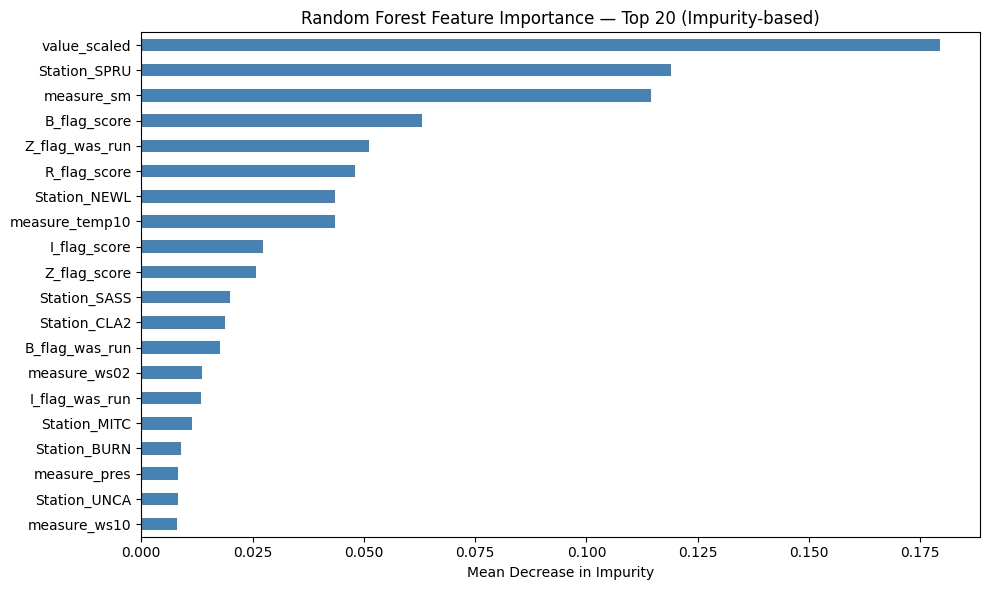

Importance sum: 1.0000


In [ ]:
# Random Forest Built-In Feature Importance

rf_clf = rf_grid_search.best_estimator_.named_steps['classifier']
rf_importances = pd.Series(rf_clf.feature_importances_, index=feature_names)
top20_rf = rf_importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20_rf.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importance — Top 20 (Impurity-based)')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

# Sanity check: importances should sum to 1
print(f'Importance sum: {rf_clf.feature_importances_.sum():.4f}')


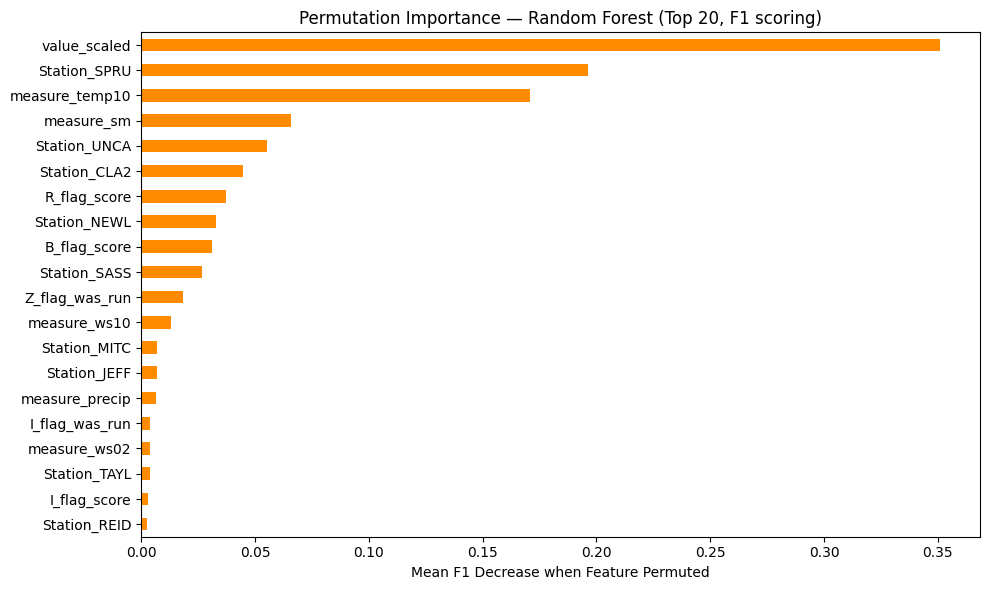

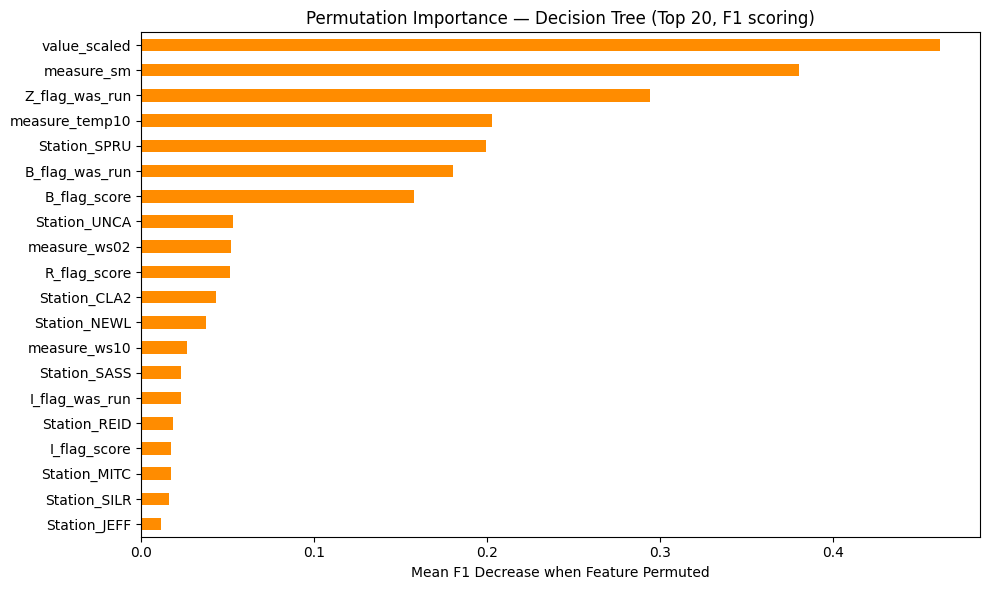

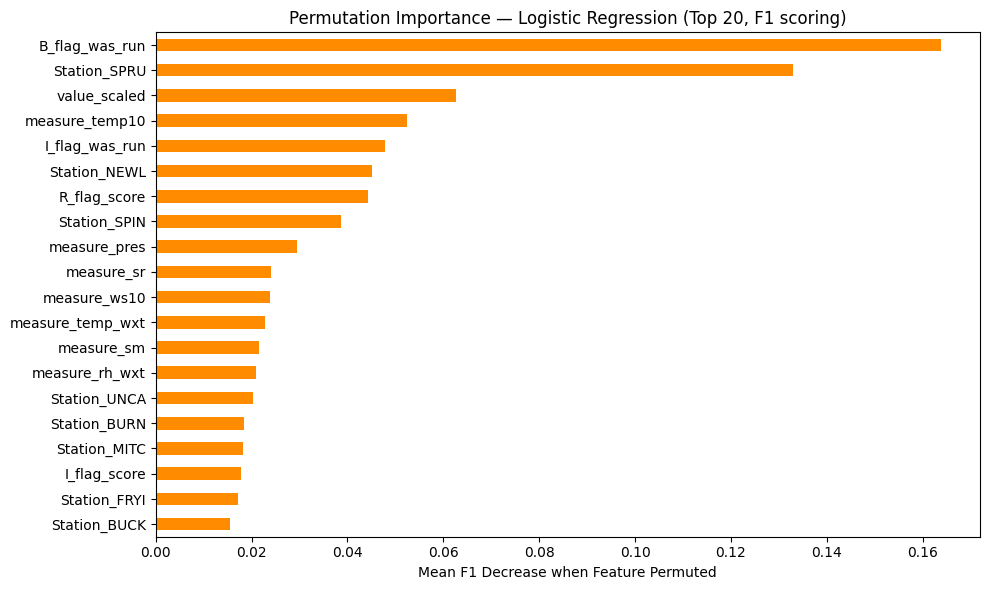

In [ ]:
# Permutation Feature Importance (RF, DT, LR)

perm_sample_size = 5000
perm_idx = rng.choice(X_test_transformed.shape[0], size=perm_sample_size, replace=False)
X_perm = X_test_transformed[perm_idx]
y_perm = y_test.iloc[perm_idx]

models_for_perm = {
    'Random Forest': rf_grid_search.best_estimator_.named_steps['classifier'],
    'Decision Tree': dt_grid_search.best_estimator_.named_steps['classifier'],
    'Logistic Regression': lr_grid_search.best_estimator_.named_steps['classifier'],
}

perm_results = {}
for name, model in models_for_perm.items():
    result = permutation_importance(
        model, X_perm, y_perm,
        scoring='f1',
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    perm_results[name] = pd.Series(result.importances_mean, index=feature_names)

    top20 = perm_results[name].nlargest(20)
    plt.figure(figsize=(10, 6))
    top20.sort_values().plot(kind='barh', color='darkorange')
    plt.title(f'Permutation Importance — {name} (Top 20, F1 scoring)')
    plt.xlabel('Mean F1 Decrease when Feature Permuted')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3447/3704096209.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_rf_class1, X_shap, feature_names=feature_names, max_display=20)


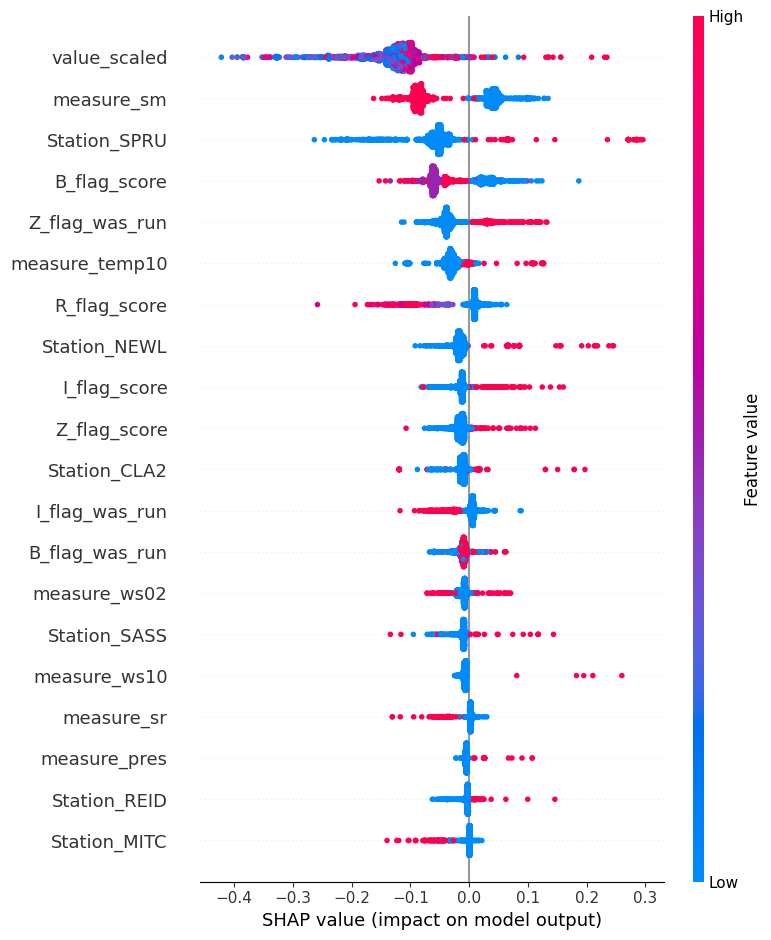

/tmp/ipykernel_3447/3704096209.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_rf_class1, X_shap, feature_names=feature_names, plot_type='bar', max_display=20)


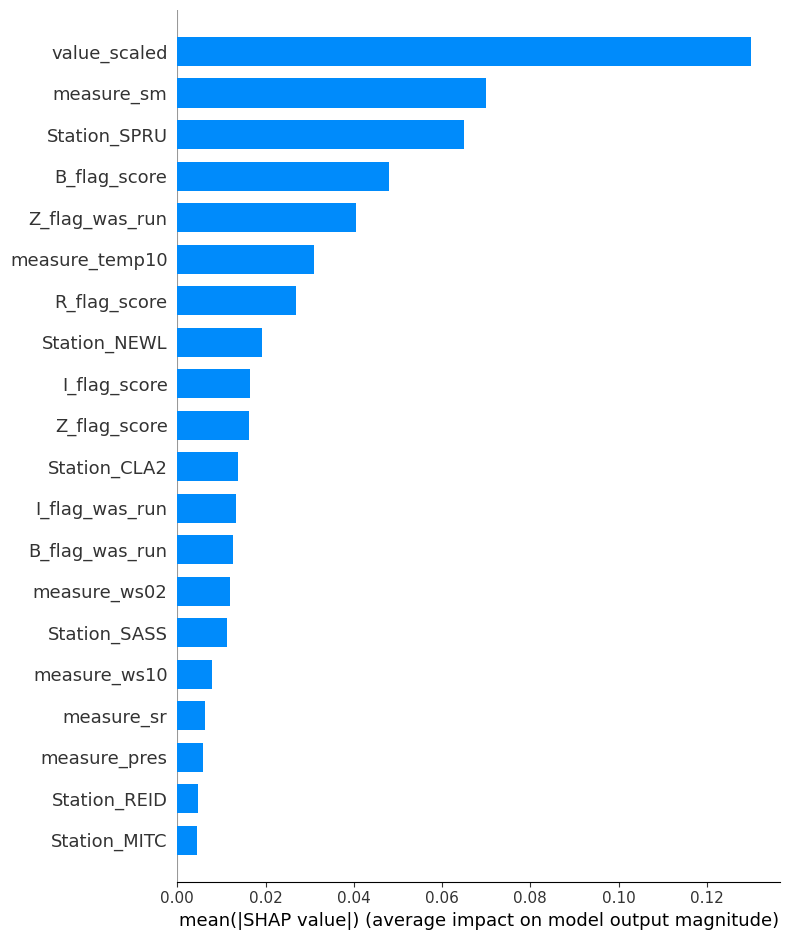

In [ ]:
# SHAP Values - Random Forest

rf_clf = rf_grid_search.best_estimator_.named_steps['classifier']
rf_explainer = shap.TreeExplainer(rf_clf)
shap_values_rf = rf_explainer.shap_values(X_shap)

# For binary classification shap_values may be a list [class0, class1] or a single array
# Use class 1 (true error) values
if isinstance(shap_values_rf, list):
    shap_rf_class1 = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    shap_rf_class1 = shap_values_rf[:, :, 1]  # slice class 1 from 3D array
else:
    shap_rf_class1 = shap_values_rf


shap.summary_plot(shap_rf_class1, X_shap, feature_names=feature_names, max_display=20)
shap.summary_plot(shap_rf_class1, X_shap, feature_names=feature_names, plot_type='bar', max_display=20)

/tmp/ipykernel_3447/3868622944.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_dt_class1, X_shap, feature_names=feature_names, max_display=20)


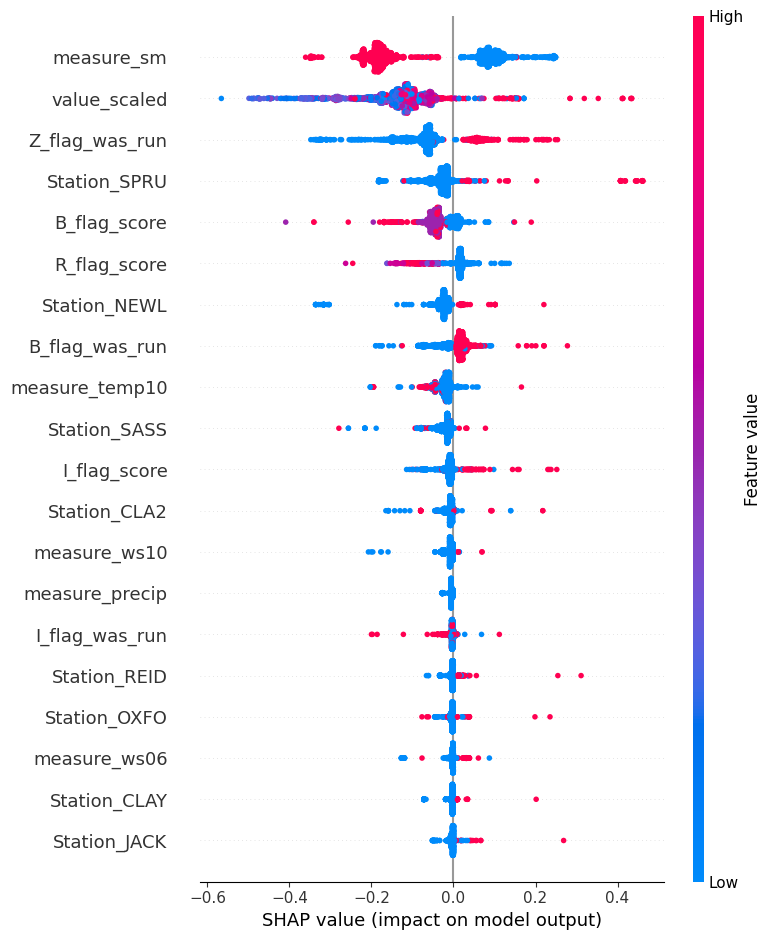

In [ ]:
# SHAP Values - Decision Tree

dt_clf = dt_grid_search.best_estimator_.named_steps['classifier']
dt_explainer = shap.TreeExplainer(dt_clf)
shap_values_dt = dt_explainer.shap_values(X_shap)

if isinstance(shap_values_dt, list):
    shap_dt_class1 = shap_values_dt[1]
elif shap_values_dt.ndim == 3:
    shap_dt_class1 = shap_values_dt[:, :, 1]
else:
    shap_dt_class1 = shap_values_dt

shap.summary_plot(shap_dt_class1, X_shap, feature_names=feature_names, max_display=20)

/tmp/ipykernel_3447/858142368.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_shap, feature_names=feature_names,


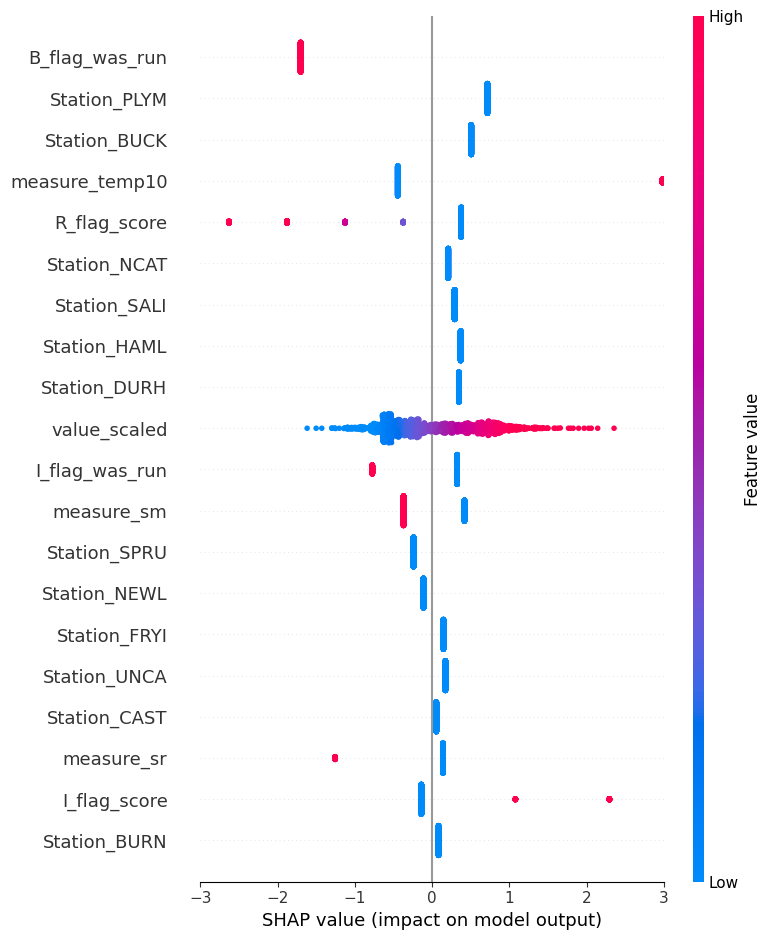

In [ ]:
# SHAP Values - Logistic Regression

lr_clf = lr_grid_search.best_estimator_.named_steps['classifier']

background = shap.maskers.Independent(X_test_transformed, max_samples=200)
lr_explainer = shap.LinearExplainer(lr_clf, background)
shap_values_lr = lr_explainer.shap_values(X_shap)

shap.summary_plot(shap_values_lr, X_shap, feature_names=feature_names,
                  max_display=20, show=False)
plt.xlim(-3, 3)
plt.tight_layout()
plt.show()

In [ ]:
# Cross-Method Feature Importance Comparison for RF

if shap_rf_class1.ndim == 2:
    shap_mean_rf = np.abs(shap_rf_class1).mean(axis=0)
else:
    shap_mean_rf = np.abs(shap_rf_class1[:, :, 1]).mean(axis=0)
shap_rank = pd.Series(shap_mean_rf, index=feature_names).nlargest(10).index.tolist()
rf_rank = rf_importances.nlargest(10).index.tolist()
perm_rank = perm_results['Random Forest'].nlargest(10).index.tolist()

max_len = max(len(shap_rank), len(rf_rank), len(perm_rank))
summary_df = pd.DataFrame({
    'RF Impurity (Top 10)': rf_rank + [''] * (max_len - len(rf_rank)),
    'RF Permutation (Top 10)': perm_rank + [''] * (max_len - len(perm_rank)),
    'RF SHAP (Top 10)': shap_rank + [''] * (max_len - len(shap_rank)),
})
print(summary_df.to_string(index=True))

  RF Impurity (Top 10) RF Permutation (Top 10) RF SHAP (Top 10)
0         value_scaled            value_scaled     value_scaled
1         Station_SPRU            Station_SPRU       measure_sm
2           measure_sm          measure_temp10     Station_SPRU
3         B_flag_score              measure_sm     B_flag_score
4       Z_flag_was_run            Station_UNCA   Z_flag_was_run
5         R_flag_score            Station_CLA2   measure_temp10
6         Station_NEWL            R_flag_score     R_flag_score
7       measure_temp10            Station_NEWL     Station_NEWL
8         I_flag_score            B_flag_score     I_flag_score
9         Z_flag_score            Station_SASS     Z_flag_score


In [ ]:
# Cross-Method Feature Importance Comparison for RF, DT, & LR

perm_rank_rf = perm_results['Random Forest'].nlargest(10).index.tolist()
perm_rank_dt = perm_results['Decision Tree'].nlargest(10).index.tolist()
perm_rank_lr = perm_results['Logistic Regression'].nlargest(10).index.tolist()

max_len = max(len(perm_rank_rf), len(perm_rank_dt), len(perm_rank_lr))
cross_model_df = pd.DataFrame({
    'RF Permutation (Top 10)': perm_rank_rf + [''] * (max_len - len(perm_rank_rf)),
    'DT Permutation (Top 10)': perm_rank_dt + [''] * (max_len - len(perm_rank_dt)),
    'LR Permutation (Top 10)': perm_rank_lr + [''] * (max_len - len(perm_rank_lr)),
})
print(cross_model_df.to_string(index=True))

  RF Permutation (Top 10) DT Permutation (Top 10) LR Permutation (Top 10)
0            value_scaled            value_scaled          B_flag_was_run
1            Station_SPRU              measure_sm            Station_SPRU
2          measure_temp10          Z_flag_was_run            value_scaled
3              measure_sm          measure_temp10          measure_temp10
4            Station_UNCA            Station_SPRU          I_flag_was_run
5            Station_CLA2          B_flag_was_run            Station_NEWL
6            R_flag_score            B_flag_score            R_flag_score
7            Station_NEWL            Station_UNCA            Station_SPIN
8            B_flag_score            measure_ws02            measure_pres
9            Station_SASS            R_flag_score              measure_sr
